<a href="https://colab.research.google.com/github/imannolM/agente-topo/blob/main/agente_topo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intalar dependencias

In [357]:
%pip install -q langchain
%pip install -q langgraph
%pip install -q langchain-community
%pip install -q langchain-cohere
%pip install -q langchain-groq
%pip install -q faiss-cpu langchain-text-splitters pymupdf
%pip install -q requests
%pip install -q langchain-classic
%pip install -q pymysql
%pip install -q mysql-connector-python

#las pasaremos a un requirements.txt

In [358]:
#las pasaremos a un .env
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
COHERE_API_KEY = userdata.get('COHERE_API_KEY')

# Conexión con LLMs

In [359]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    groq_api_key = GROQ_API_KEY,
    temperature = 0
)

## Creamos el prompt_triaje y la función triaje

In [360]:
PROMPT_TRIAJE = '''
Eres un clasificador y enrutador automático para el despacho inmobiliario Terrenos TOPO.
Tu ÚNICA tarea es invocar la función de clasificación con los campos "decision", "urgencia" y "campos_faltantes".
NUNCA respondas la pregunta del usuario, NUNCA generes texto libre, NUNCA expliques nada. Solo clasifica.

Analiza el mensaje del usuario (que puede ser un Cliente, Empleado o Administrador) y clasifícalo en una de las siguientes opciones según su intención, sin importar si conoces la respuesta:

- CONSULTAR_DOCUMENTACION: El mensaje pregunta sobre aspectos teóricos, políticas, requisitos legales, procesos internos, servicios de los 4 departamentos (Topografía, Jurídico, Administrativo, Bienes Raíces) o terrenos disponibles en general. (Se resolverá buscando en los PDFs de la base de conocimiento).

- CONSULTAR_DB: El usuario quiere consultar datos específicos, dinámicos o numéricos registrados en el sistema. Ejemplos: consultar el estado de un trámite mediante un "folio", saber cuántas ventas ha realizado un socio, revisar estados de cuenta o estatus de expedientes específicos.

- MODIFICAR_DB_O_DOCS: El usuario solicita explícitamente agregar, eliminar, actualizar registros en la base de datos, o subir/borrar documentos del sistema (Acción exclusiva de administración o peticiones de empleados).

- ANALISIS_DATOS: El usuario (Administrador, o un Socio verificado como "Imannol Monroy") solicita explícitamente cálculos estadísticos, promedios, resúmenes avanzados o la generación de GRÁFICOS y reportes visuales complejos sobre tablas de ventas o métricas anuales de la empresa.

- PEDIR_INFO: El mensaje es ambiguo, irrelevante o no tiene ninguna relación con Terrenos TOPO (ej. cultura general, saludos sin contexto claro, o temas ajenos a los 4 departamentos).

- AGENDAR_CITA: El cliente pide explícitamente agendar una cita o hablar directamente con un asesor humano.

Ante la duda entre CONSULTAR_DOCUMENTACION y PEDIR_INFO, prefiere CONSULTAR_DOCUMENTACION si el tema se relaciona con ingeniería, catastro, legal o inmobiliario.

Recuerda: SIEMPRE debes invocar la función de clasificación. Jamás respondas con texto libre.
'''

In [361]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["CONSULTAR_DOCUMENTACION", "CONSULTAR_DB", "MODIFICAR_DB_O_DOCS", "ANALISIS_DATOS", "PEDIR_INFO", "AGENDAR_CITA"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [362]:
from langchain_core.messages import content
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm_groq.with_structured_output(TriajeOut)

# --- FUNCIÓN TRIAJE ---
def triaje(mensaje: str) -> Dict:
    try:
        salida: TriajeOut = chain_de_triaje.invoke(
            [
                SystemMessage(content=PROMPT_TRIAJE),
                HumanMessage(content=mensaje)
            ]
        )
        return salida.model_dump()
    except Exception as e:
        print(f"⚠️ Error en triaje, usando fallback PEDIR_INFO: {e}")
        return {
            "decision": "PEDIR_INFO",
            "urgencia": "BAJA",
            "campos_faltantes": []
        }

# RAG

In [363]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/drive/MyDrive/documentos-topo").glob("*.pdf"):
  try:
    loader = PyMuPDFLoader(str(documento))
    docs.extend(loader.load())
    print(f"Archivo cargado: {documento.name}")
  except Exception as e:
    print(f"Error cargando archivo: {documento.name}: {e}")

print(f'Total de documentos cargados: {len(docs)}')

Archivo cargado: 01_perfil_corporativo.pdf
Archivo cargado: 02_departamento_topografia.pdf
Archivo cargado: 03_departamento_juridico.pdf
Archivo cargado: 04_departamento_administrativo.pdf
Archivo cargado: 06_departamento_bienes_raices.pdf
Archivo cargado: 05_administracion_financiera.pdf
Archivo cargado: 07_politicas_generales.pdf
Archivo cargado: 08_faqs_por_usuario.pdf
Total de documentos cargados: 37


Text Splitting (Segmentación)

In [364]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size = 300, chunk_overlap = 30)
chunks = splitter.split_documents(docs)
print(f'Total de chunks: {len(chunks)}')

Total de chunks: 339


In [365]:
#podemos ver los chunks si es necesario
# for chunk in chunks:
#   print(chunk)
#   print('_________________________')

Embedding (vectorización)

In [366]:
from langchain_cohere import CohereEmbeddings

modelo_embeddings = CohereEmbeddings(
    model="embed-multilingual-v3.0",
    cohere_api_key = COHERE_API_KEY
)

In [367]:
from re import search
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type = 'similarity_score_threshold',
    search_kwargs = {'score_threshold': 0.3, 'k': 4}
)

Creamos el prompt del RAG

In [368]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

# Modificamos el System Prompt con las directrices específicas del proyecto
PROMPT_RAG_TOPO = """
Eres el asistente experto y especialista del despacho inmobiliario Terrenos TOPO.
Tu objetivo es responder de forma clara, profesional y concisa las consultas sobre la documentación y políticas de la empresa (Topografía, Jurídico, Administrativo y Bienes Raíces).

REGLAS ESTRICTAS DE OPERACIÓN:
1. Responde ÚNICAMENTE utilizando el fragmento de contexto provisto, el cual proviene de los documentos institucionales oficiales de la empresa.
2. Si la respuesta no se encuentra explícitamente en el contexto proporcionado, di de forma directa y amable: "Lo siento, no dispongo de información oficial sobre ese tema en este momento." No intentes inventar ni adivinar datos.
3. Adapta sutilmente tu tono según el contexto de la consulta (sé servicial con Clientes, técnico y colaborativo con Empleados/Socios, y formal con el Administrador).
4. NUNCA menciones términos técnicos del sistema como "los fragmentos de texto provistos", "según el contexto enviado" o "el RAG". Para el usuario, tú conoces la empresa a la perfección de forma natural.
"""

prompt_rag = ChatPromptTemplate(
    [
        ('system', PROMPT_RAG_TOPO),
        ('human', 'Contexto de los documentos oficiales:\n{context}\n\nPregunta formulada: {input}')
    ]
)

document_chain = create_stuff_documents_chain(llm_groq, prompt_rag)

Creamos la función que estructura la únion del retriever y document_chain. Creamos la función RAG

In [369]:
# --- FUNCIÓN RAG (Sincronizada con el prompt amigable de Terrenos TOPO) ---
def busqueda_de_respuestas_RAG(pregunta: str) -> Dict:
    documentos_relacionados = retriever.invoke(pregunta)
    frase_no_info = "Lo siento, no dispongo de información oficial sobre ese tema en este momento."

    if not documentos_relacionados:
        return {
            'respuesta': frase_no_info,
            'citaciones': [],
            'documentos_encontrados': False
        }

    answer = document_chain.invoke({
        'input': pregunta,
        'context': documentos_relacionados
    })

    # Verificamos si el LLM generó la frase de contingencia
    if answer.strip().rstrip('.!?') == frase_no_info.rstrip('.!?'):
        return {
            'respuesta': frase_no_info,
            'citaciones': [],
            'documentos_encontrados': False
        }

    return {
        'respuesta': answer,
        'citaciones': documentos_relacionados,
        'documentos_encontrados': True
    }

In [370]:
r = busqueda_de_respuestas_RAG('Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer?')
print(r)

{'respuesta': 'Para actualizar tus datos catastrales debido a la diferencia en la superficie real y la escriturada, es recomendable realizar un levantamiento topográfico catastral. Este proceso implica la medición precisa de la superficie del predio por un perito topográfico. \n\nUna vez que se obtengan los resultados del levantamiento, si se confirma que la superficie real es distinta a la escriturada, el perito topográfico te orientará sobre el trámite de corrección de superficie que deberás seguir. Este trámite generalmente se gestiona en coordinación con el departamento Jurídico.\n\nAdemás, es importante verificar el requisito específico de la autoridad ante la que se presentará el documento, ya que las autoridades catastrales suelen solicitar levantamientos con una antigüedad no mayor a 6-12 meses.\n\nEl costo del levantamiento topográfico catastral puede variar según la superficie del predio, pero el costo de la actualización del padrón tras un deslinde, corrección de superficie 

In [371]:
len(r['citaciones'])

4

# Agente con LangGraph

In [372]:
from typing import TypedDict, List, Dict, Any, Optional, Annotated, Sequence
from langchain_core.messages import BaseMessage

# 1. Definimos AgentState, expandido solo con los roles de seguridad
class AgentState(TypedDict, total=False):
    messages: list
    triaje: dict
    respuesta: Optional[str]
    citaciones: Optional[list]
    rag_exito: bool
    accion_final: str
    # Agregados obligatorios para el control de Terrenos TOPO:
    user_role: str        # "administrador", "empleado", "cliente"
    folio: Optional[str]  # Folio de trámite si es cliente

Vamos a crear una función auxiliar de apoyo

In [373]:
# --- FUNCIÓN AUXILIAR DE APOYO ---
def obtener_pregunta_del_estado(state: AgentState) -> str:
    """Extrae de forma segura el texto de la pregunta desde los mensajes del estado."""
    if "messages" not in state or not state["messages"]:
        if "pregunta" in state:
            return state["pregunta"]
        raise KeyError("El estado no contiene 'messages' ni 'pregunta'. Revisa tu AgentState.")

    ultimo_mensaje = state["messages"][-1]
    if isinstance(ultimo_mensaje, tuple):
        return ultimo_mensaje[1]
    elif hasattr(ultimo_mensaje, "content"):
        return ultimo_mensaje.content
    return str(ultimo_mensaje)

In [374]:
# --- NODO: TRIAJE ---
def nodo_triaje(state: AgentState) -> dict:
    print("🔮 Ejecutando nodo triaje...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    print(f"💬 Pregunta procesada para triaje: '{texto_pregunta}'")
    return {"triaje": triaje(texto_pregunta)}

In [375]:
# --- NODO: CONSULTAR DOCUMENTACIÓN (RAG) ---
def nodo_consultar_documentacion(state: AgentState) -> dict:
    print("📚 Ejecutando nodo consultar_documentacion (RAG)...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    respuesta_RAG = busqueda_de_respuestas_RAG(texto_pregunta)

    update = {
        "respuesta": respuesta_RAG["respuesta"],
        "citaciones": respuesta_RAG["citaciones"],
        "rag_exito": respuesta_RAG["documentos_encontrados"]
    }

    if respuesta_RAG["documentos_encontrados"]:
        update["accion_final"] = "DOCUMENTACION_RESUELTA"
    else:
        update["accion_final"] = "PEDIR_INFO"

    return update

A partir de aquí crearemos las funciones lógicas para los nodos restantes.

Usaremos Aiven para la db

In [376]:
# montamos drive
from google.colab import drive
drive.mount('/content/drive')

# Conexión con Aiven
import mysql.connector

HOST_AIVEN = userdata.get('HOST_AIVEN')
PORT_AIVEN = userdata.get('PORT_AIVEN')
USER_AIVEN = userdata.get('USER_AIVEN')
PASSWORD_AIVEN = userdata.get('PASSWORD_AIVEN')
DATABASE_AIVEN = userdata.get('DATABASE_AIVEN')

conn = mysql.connector.connect(
    host=HOST_AIVEN,
    port=PORT_AIVEN,
    user=USER_AIVEN,
    password=PASSWORD_AIVEN,
    database=DATABASE_AIVEN,
    ssl_ca="/content/drive/MyDrive/documentos-topo/ca.pem"
)
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM ventas_analitica;")
print(cursor.fetchone())

cursor.execute("SHOW DATABASES;")
for db in cursor:
    print(db)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000,)
('defaultdb',)
('information_schema',)
('mysql',)
('performance_schema',)
('sys',)
('terrenos_topo_db',)


In [377]:
def obtener_conexion_db():
    HOST_AIVEN = userdata.get('HOST_AIVEN')
    PORT_AIVEN = userdata.get('PORT_AIVEN')
    USER_AIVEN = userdata.get('USER_AIVEN')
    PASSWORD_AIVEN = userdata.get('PASSWORD_AIVEN')
    DATABASE_AIVEN = userdata.get('DATABASE_AIVEN')

    return mysql.connector.connect(
        host=HOST_AIVEN,
        port=PORT_AIVEN,
        user=USER_AIVEN,
        password=PASSWORD_AIVEN,
        database=DATABASE_AIVEN,
        ssl_ca="/content/drive/MyDrive/documentos-topo/ca.pem"
    )

In [378]:
# --- FUNCIÓN LOGICA: CONSULTAR BASE DE DATOS (SCONZADA CON SQL REAL) ---
def consulta_base_de_datos(pregunta: str, user_role: str, folio: str = None) -> dict:
    print(f"⚙️ Procesando consulta real de DB en Aiven para el rol: {user_role}")
    try:
        conexion = obtener_conexion_db()
        with conexion.cursor() as cursor:
            if folio:
                # Sincronizado al 100% con tu esquema SQL real:
                sql = "SELECT id_tramite, tipo_tramite, estatus FROM juridico_tramites WHERE id_tramite LIKE %s"
                cursor.execute(sql, (f"%{folio}%",))
                resultado = cursor.fetchone()

                if resultado:
                    if isinstance(resultado, dict):
                        id_t = resultado.get("id_tramite")
                        tipo = resultado.get("tipo_tramite", "No especificado")
                        status = resultado.get("estatus", "No definido")
                    else:
                        id_t = resultado[0]
                        tipo = resultado[2]
                        status = resultado[6] # 'estatus' es la 7ma columna (índice 6) según tu SQL

                    respuesta = f"Resultados para el trámite {id_t}: Tipo de trámite: {tipo}. Estado actual: {status}."
                else:
                    respuesta = f"No se encontró ningún registro asociado al folio/id {folio} en la tabla 'juridico_tramites' de Aiven."

            elif user_role in ["administrador", "admin", "empleado"]:
                sql = "SELECT COUNT(*) FROM ventas_analitica"
                cursor.execute(sql)
                resultado = cursor.fetchone()
                total = resultado.get("COUNT(*)") if isinstance(resultado, dict) else resultado[0]
                respuesta = f"Consulta general exitosa. Total de registros en ventas_analitica: {total}."
            else:
                respuesta = "Para consultar el estado de tu trámite, por favor proporciona tu número de folio o id."

        conexion.close()
        return {"respuesta": respuesta, "db_exito": True}
    except Exception as e:
        print(f"❌ Error de conexión a MySQL en Aiven: {e}")
        return {"respuesta": "Lo siento, hubo un problema al conectar con el sistema de base de datos de Aiven.", "db_exito": False}

# --- FUNCIÓN LOGICA: MODIFICAR BASE DE DATOS (SINCROZADA CON SQL REAL) ---
def modificacion_base_de_datos(pregunta: str, user_role: str, datos_modificacion: dict = None) -> Dict:
    print(f"🔒 Validando permisos de escritura para el rol: {user_role}")

    if user_role not in ["administrador", "admin", "empleado"]:
        return {
            "respuesta": "Acceso denegado. No tienes permisos suficientes para realizar modificaciones en el sistema.",
            "db_exito": False
        }

    try:
        conexion = obtener_conexion_db()
        with conexion.cursor() as cursor:
            # Actualizamos la tabla correcta 'juridico_tramites' y su columna 'estatus'
            sql = "UPDATE juridico_tramites SET estatus = %s WHERE id_tramite LIKE %s"
            folio_target = datos_modificacion.get('folio') if datos_modificacion else '1005'

            cursor.execute(sql, ("en_desarrollo", f"%{folio_target}%")) # 'en_desarrollo' es un ENUM válido en tu SQL
            conexion.commit()

        conexion.close()
        return {
            "respuesta": f"El trámite asociado al identificador {folio_target} ha sido actualizado correctamente a 'en_desarrollo' en la tabla juridico_tramites de Aiven.",
            "db_exito": True
        }
    except Exception as e:
        print(f"❌ Error de escritura en MySQL de Aiven: {e}")
        return {"respuesta": "Error al intentar guardar los cambios en la base de datos.", "db_exito": False}

# --- FUNCIÓN LOGICA: PEDIR INFORMACIÓN / SOPORTE ---
def soporte_pedir_info(pregunta: str) -> Dict:
    # Lógica para responder cuando algo es ambiguo o fuera de contexto
    return {
        "respuesta": "Para poder ayudarte mejor en Terrenos TOPO, ¿podrías ser un poco más específico con tu consulta o indicarme con qué departamento deseas hablar?",
        "info_completada": False
    }

# --- FUNCIÓN LOGICA: AGENDAR CITA ---
def gestion_agendar_cita(pregunta: str) -> Dict:
    # Nota: Aquí conectaremos con Google Calendar o una tabla de citas en el Chat 5
    return {
        "respuesta": "¡Por supuesto! Para agendar una cita con uno de nuestros asesores de Terrenos TOPO, por favor indícame tu nombre completo, teléfono y el día de tu preferencia.",
        "cita_agendada": False
    }

Aquí crearemos los nodos que interactúan directamente con al AgentState

In [379]:
import re
# --- NODO: CONSULTAR DB ---
def nodo_consultar_db(state: AgentState) -> dict:
    print("🗄️ Ejecutando nodo consultar_db...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    rol = state.get("user_role", "cliente")

    # Intentamos obtener el folio del estado
    folio_tramite = state.get("folio", None)

    # Si no está en el estado, lo buscamos directamente en el texto con Regex (ej. 1005 o F-1005)
    if not folio_tramite:
        match = re.search(r'\b\d{4,5}\b', texto_pregunta) # Busca números de 4 o 5 dígitos
        if match:
            folio_tramite = match.group(0)
            print(f"📌 Folio detectado automáticamente en el texto: {folio_tramite}")

    resultado_db = consulta_base_de_datos(texto_pregunta, user_role=rol, folio=folio_tramite)

    return {
        "respuesta": resultado_db["respuesta"],
        "accion_final": "CONSULTA_DB_PROCESADA",
        "folio": folio_tramite # Lo guardamos en el estado para futuros nodos
    }

# --- NODO: MODIFICAR DB O DOCS ---
def nodo_modificar_db_o_docs(state: AgentState) -> dict:
    print("✍️ Ejecutando nodo modificar_db_o_docs...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    rol = state.get("user_role", "cliente")

    # Extraemos el folio dinámicamente si no viene en el estado
    folio_tramite = state.get("folio", None)
    if not folio_tramite:
        match = re.search(r'\b\d{4,5}\b', texto_pregunta)
        if match:
            folio_tramite = match.group(0)
            print(f"📌 Folio detectado automáticamente para modificación: {folio_tramite}")

    datos_simulados = {"folio": folio_tramite if folio_tramite else "1005"}
    resultado_modificacion = modificacion_base_de_datos(texto_pregunta, user_role=rol, datos_modificacion=datos_simulados)

    update = {
        "respuesta": resultado_modificacion["respuesta"],
        "folio": folio_tramite
    }

    if resultado_modificacion["db_exito"]:
        update["accion_final"] = "MODIFICACION_EXITOSA"
    else:
        update["accion_final"] = "ERROR_PERMISOS"

    return update

# --- NODO: PEDIR INFO ---
def nodo_pedir_info(state: AgentState) -> dict:
    print("💬 Ejecutando nodo pedir_info...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    resultado_soporte = soporte_pedir_info(texto_pregunta)

    return {
        "respuesta": resultado_soporte["respuesta"],
        "accion_final": "PEDIR_INFO_CLIENTE"
    }

# --- NODO: AGENDAR CITA ---
def nodo_agendar_cita(state: AgentState) -> dict:
    print("📅 Ejecutando nodo agendar_cita...")
    texto_pregunta = obtener_pregunta_del_estado(state)

    resultado_cita = gestion_agendar_cita(texto_pregunta)

    return {
        "respuesta": resultado_cita["respuesta"],
        "accion_final": "SOLICITAR_DATOS_CITA"
    }

A partir de aquí, crearemos las herrmaientas de análisis de datos ya que hemos añadido esta función al agente (Se ha modificado por lo tanto el PROMT_TRIAJE)

In [380]:
import pandas as pd
from langchain_core.tools import tool
from sqlalchemy import create_engine
import pymysql
import urllib.parse


# Función auxiliar para extraer el DataFrame real desde Aiven de forma dinámica
def extraer_df_desde_mysql(nombre_tabla: str) -> pd.DataFrame:
    usuario = userdata.get('USER_AIVEN')
    password = urllib.parse.quote_plus(userdata.get('PASSWORD_AIVEN')) # Por si el password de Aiven tiene caracteres especiales
    host = userdata.get('HOST_AIVEN')
    puerto = userdata.get('PORT_AIVEN')
    db = userdata.get('DATABASE_AIVEN')

    # Ruta al certificado SSL
    ssl_ca = "/content/drive/MyDrive/documentos-topo/ca.pem"

    # Creamos la URI de conexión incluyendo el parámetro del certificado para MySQL
    conexion_uri = f"mysql+pymysql://{usuario}:{password}@{host}:{puerto}/{db}?ssl_ca={ssl_ca}"

    engine = create_engine(conexion_uri)
    return pd.read_sql(f"SELECT * FROM `{nombre_tabla}`", con=engine)

# Declaramos las 4 herramientas replicando la estructura del cuaderno,
# pero permitiendo recibir el DataFrame dinámico.

def crear_herramientas_analisis(df: pd.DataFrame):

    @tool
    def informaciones_df() -> str:
        """Muestra los nombres de las columnas, tipos de datos y los primeros registros del conjunto de datos."""
        info = f"Columnas y Tipos:\n{df.dtypes.to_string()}\n\nMuestra de datos:\n{df.head(3).to_string()}"
        return info

    @tool
    def resumen_estadistico() -> str:
        """Genera un resumen estadístico detallado de las variables numéricas y categóricas del conjunto de datos."""
        return df.describe(include='all').to_string()

    @tool
    def generar_grafico(codigo_plot: str) -> str:
        """Ejecuta código de matplotlib/seaborn para generar y guardar un gráfico.
        El código debe asumir que el dataframe ya se encuentra cargado en la variable 'df'."""
        import matplotlib.pyplot as plt
        import seaborn as sns
        import io

        try:
            plt.figure(figsize=(8, 4))
            sns.set_theme()
            # Ejecutamos el código en un entorno controlado donde 'df' ya existe
            exec(codigo_plot, {"df": df, "plt": plt, "sns": sns, "pd": pd})
            plt.savefig("grafico_analisis.png", bbox_inches='tight')
            plt.close()
            return "Gráfico generado exitosamente y guardado como 'grafico_analisis.png'."
        except Exception as e:
            return f"Error al generar el gráfico: {str(e)}"

    @tool
    def herramienta_codigos_python(codigo_analisis: str) -> str:
        """Ejecuta cualquier código Python necesario para realizar cálculos personalizados sobre el dataframe 'df' y devuelve el resultado en texto."""
        try:
            local_vars = {"df": df}
            exec(codigo_analisis, {}, local_vars)
            # Intentamos retornar el output si el código asignó un resultado
            return str(local_vars.get("resultado", "Código ejecutado correctamente sin variable 'resultado' asignada."))
        except Exception as e:
            return f"Error en la ejecución del código: {str(e)}"

    return [informaciones_df, resumen_estadistico, generar_grafico, herramienta_codigos_python]


In [381]:
# Creamos el nodo_analisis_datos
from langchain_classic.agents import create_react_agent, AgentExecutor
from langchain_core.prompts import PromptTemplate

# --- NODO: ANÁLISIS DE DATOS (CORRECCIÓN AGENT_SCRATCHPAD) ---
def nodo_analisis_datos(state: AgentState) -> dict:
    print("📊 Ejecutando nodo de análisis de datos (MySQL Data)...")
    texto_pregunta = obtener_pregunta_del_estado(state)
    nombre_tabla = state.get("folio", "ventas_analitica")

    try:
        df = extraer_df_desde_mysql(nombre_tabla)
    except Exception as e:
        return {"respuesta": f"Error al conectar con la tabla '{nombre_tabla}' en Aiven: {e}", "accion_final": "ANALISIS_FALLIDO"}

    herramientas = crear_herramientas_analisis(df)

    # 🌟 CORRECCIÓN: Inyectamos el 'nombre_tabla' usando una f-string clásica en Python
    # para que no quede como una variable pendiente de LangChain.
    template_react = f"""Eres un experto en análisis de datos para Terrenos TOPO.
Tienes acceso a las siguientes herramientas para consultar la tabla '{nombre_tabla}':

{{tools}}

Para usar una herramienta, debes usar obligatoriamente el siguiente formato exacto:

Thought: Do I need to use a tool? Yes
Action: la acción que vas a tomar, debe ser obligatoriamente uno de estos nombres: [{{tool_names}}]
Action Input: la entrada de la herramienta
Observation: el resultado que te arrojó la herramienta

... (puedes repetir este proceso de Thought/Action/Action Input/Observation varias veces si es necesario)

Cuando ya tengas la conclusión final y no requieras herramientas, usa este formato:

Thought: I know the final answer
Final Answer: tu respuesta analítica bien redactada en español aquí.

Reglas obligatorias:
1. Utiliza siempre 'informaciones_df' o 'resumen_estadistico' antes de realizar cualquier cálculo matemático para conocer los datos de la tabla '{nombre_tabla}'.
2. Si te piden un gráfico, escribe el código necesario y envíalo a la herramienta 'generar_grafico'.
3. Responde siempre de forma clara y analítica en español.

Pregunta del usuario: {{input}}
Thought: {{agent_scratchpad}}"""

    # Al usar from_template, LangChain solo detectará como variables: {tools}, {tool_names}, {input} y {agent_scratchpad}
    prompt = PromptTemplate.from_template(template_react)

    agente = create_react_agent(llm_groq, herramientas, prompt)
    ejecutor = AgentExecutor(agent=agente, tools=herramientas, verbose=True, handle_parsing_errors=True)

    resultado = ejecutor.invoke({"input": texto_pregunta})

    return {
        "respuesta": resultado["output"],
        "accion_final": "ANALISIS_COMPLETADO"
    }

Aquí implementaremos aristas de desición



In [382]:
def arista_decision_triaje(state: AgentState) -> str:
    print("🔮 Decidiendo el flujo después del nodo 'triaje'...")
    tri = state["triaje"]
    decision = tri.get("decision")

    if decision == "CONSULTAR_DOCUMENTACION":
        print(" -> Ruta seleccionada: Base de Conocimiento (RAG)")
        return "rag"
    elif decision == "CONSULTAR_DB":
        print(" -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)")
        return "consultar_db"
    elif decision == "MODIFICAR_DB_O_DOCS":
        print(" -> Ruta seleccionada: Modificación de registros")
        return "modificar_db"
    elif decision == "ANALISIS_DATOS":
        print(" -> Ruta seleccionada: Módulo de analítica y gráficos")
        return "analizar_datos"
    elif decision == "AGENDAR_CITA":
        print(" -> Ruta seleccionada: Agenda/Asesor humano")
        return "cita"
    else:
        print(" -> Ruta seleccionada: Pedir más información / Caso ambiguo")
        return "info"

In [383]:
def arista_decision_rag(state: AgentState) -> str:
    print("📝 Decidiendo el flujo después del nodo 'consultar_documentacion' (RAG)...")

    # Suponiendo que tu nodo de documentación guarda un flag 'rag_exito'
    if state.get("rag_exito"):
        print("RAG exitoso, finalizando el flujo.")
        return "ok"

    # Palabras clave adaptadas al contexto inmobiliario/topográfico de Terrenos TOPO
    KEYWORDS_AGENDAR_CITA = [
        "aprobacion", "aprobar", "excepcion", "liberacion", "autorizacion",
        "autorizar", "levantamiento", "deslinde", "firma de contrato", "asesor"
    ]

    if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_AGENDAR_CITA):
        print("El RAG no bastó, pero detectamos intención de cita presencial o técnica.")
        return "cita"

    print("El RAG no encontró respuesta suficiente; solicitando aclaraciones al usuario.")
    return "info"

MAPA DEL GRAFO

In [384]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# 1. Registro de todos tus Nodos del sistema
workflow.add_node("triaje", nodo_triaje)
workflow.add_node("consultar_documentacion", nodo_consultar_documentacion)
workflow.add_node("consultar_db", nodo_consultar_db)
workflow.add_node("modificar_db", nodo_modificar_db_o_docs)
workflow.add_node("analisis_datos", nodo_analisis_datos) # El nuevo nodo con las 4 tools
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("agendar_cita", nodo_agendar_cita)

# Punto de entrada obligatorio
workflow.set_entry_point("triaje")

# 2. Aristas Condicionales desde el Triaje
workflow.add_conditional_edges(
    "triaje",
    arista_decision_triaje,
    {
        "rag": "consultar_documentacion",
        "consultar_db": "consultar_db",
        "modificar_db": "modificar_db",
        "analizar_datos": "analisis_datos",  # Enlace directo al módulo de analítica
        "cita": "agendar_cita",
        "info": "pedir_info"
    }
)

# 3. Aristas Condicionales desde el RAG (Siguiendo tu estructura del curso)
workflow.add_conditional_edges(
    "consultar_documentacion",
    arista_decision_rag,
    {
        "ok": END,                  # Si el RAG contestó bien, termina
        "cita": "agendar_cita",     # Si falló pero quiere cita, va al nodo cita
        "info": "pedir_info"        # Si falló por completo, pide más contexto
    }
)

# 4. Los demás nodos terminan directo el flujo al ejecutarse
workflow.add_edge("consultar_db", END)
workflow.add_edge("modificar_db", END)
workflow.add_edge("analisis_datos", END) # Tu nuevo flujo de datos termina limpio aquí
workflow.add_edge("pedir_info", END)
workflow.add_edge("agendar_cita", END)

# Compilación final
app = workflow.compile()

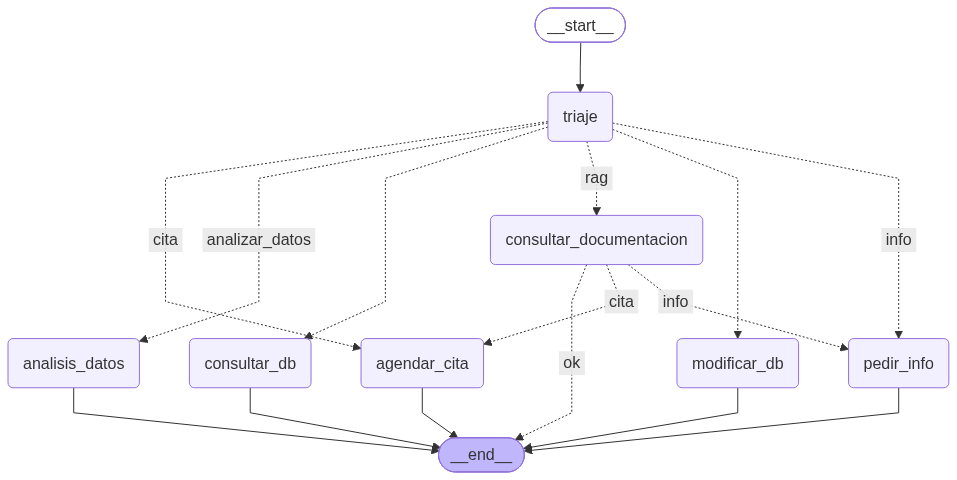

In [385]:
from IPython.display import display, Image

graph_bytes = app.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [386]:
inputs = {"messages": [("user", "Hola, me podrías decir cuál es el estado actual del trámite con el folio 1005?")]}

for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Nodo ejecutado: {key}")
        print(value)
    print("-" * 50)

🔮 Ejecutando nodo triaje...
💬 Pregunta procesada para triaje: 'Hola, me podrías decir cuál es el estado actual del trámite con el folio 1005?'
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Consulta de datos/expedientes (MySQL)
Nodo ejecutado: triaje
{'triaje': {'decision': 'CONSULTAR_DB', 'urgencia': 'MEDIANA', 'campos_faltantes': []}}
--------------------------------------------------
🗄️ Ejecutando nodo consultar_db...
📌 Folio detectado automáticamente en el texto: 1005
⚙️ Procesando consulta real de DB en Aiven para el rol: cliente
Nodo ejecutado: consultar_db
{'respuesta': "No se encontró ningún registro asociado al folio/id 1005 en la tabla 'juridico_tramites' de Aiven.", 'accion_final': 'CONSULTA_DB_PROCESADA', 'folio': '1005'}
--------------------------------------------------


In [387]:
inputs = {
    "messages": [("user", "Por favor, actualiza el estatus del folio 1005 a 'Aprobado' y pon en la descripción que ya se revisaron los planos.")],
    "user_role": "admin" # <--- Cambiamos el rol temporalmente para la prueba
}

for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Nodo ejecutado: {key}")
        print(value)
    print("-" * 50)

🔮 Ejecutando nodo triaje...
💬 Pregunta procesada para triaje: 'Por favor, actualiza el estatus del folio 1005 a 'Aprobado' y pon en la descripción que ya se revisaron los planos.'
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Modificación de registros
Nodo ejecutado: triaje
{'triaje': {'decision': 'MODIFICAR_DB_O_DOCS', 'urgencia': 'ALTA', 'campos_faltantes': []}}
--------------------------------------------------
✍️ Ejecutando nodo modificar_db_o_docs...
📌 Folio detectado automáticamente para modificación: 1005
🔒 Validando permisos de escritura para el rol: admin
Nodo ejecutado: modificar_db
{'respuesta': "El trámite asociado al identificador 1005 ha sido actualizado correctamente a 'en_desarrollo' en la tabla juridico_tramites de Aiven.", 'folio': '1005', 'accion_final': 'MODIFICACION_EXITOSA'}
--------------------------------------------------


In [388]:
inputs = {"messages": [("user", "Necesito que hagas un análisis general de la tabla de ventas analítica para ver el rendimiento total.")]}

for output in app.stream(inputs):
    for key, value in output.items():
        print(f"Nodo ejecutado: {key}")
        print(value)
    print("-" * 50)

🔮 Ejecutando nodo triaje...
💬 Pregunta procesada para triaje: 'Necesito que hagas un análisis general de la tabla de ventas analítica para ver el rendimiento total.'
🔮 Decidiendo el flujo después del nodo 'triaje'...
 -> Ruta seleccionada: Módulo de analítica y gráficos
Nodo ejecutado: triaje
{'triaje': {'decision': 'ANALISIS_DATOS', 'urgencia': 'MEDIANA', 'campos_faltantes': []}}
--------------------------------------------------
📊 Ejecutando nodo de análisis de datos (MySQL Data)...


> Entering new AgentExecutor chain...
Do I need to use a tool? Yes
Action: informaciones_df
Action Input: Columnas y Tipos:
id_venta                   object
departamento               object
tipo_operacion             object
cliente                    object
socio_responsable          object
canal_origen               object
ingreso                   float64
costo_operativo           float64
utilidad                  float64
fecha_inicio_proceso       object
fecha_cierre               object
dias_durac